# Control Systems Playground

## Table of Contents

- [1. First Order Systems](#1-first-order-systems)

- [2. Second Order Systems](#2-second-order-systems)

- [3. Filters](#3-filters)
    - [Low Pass](#31-low-pass)
    - [High Pass](#32-high-pass)
    - [Band Pass](#33-band-pass)
    - [Band Stop](#34-band-stop)

- [4. Interactive Playground](#4-interactive-playground)

In [171]:
%load_ext autoreload
%autoreload 2
# Imports
import control_utils as cu
import signals as sig
import plotting as plot
import ipywidgets as widgets

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. First Order Systems

$$
H(s) = \frac{1}{\tau s + 1}
$$

In [172]:
def widget_first_order(k=1, tau=2, use_square=False, freq=1) -> None:
    sys = cu.first_order(k, tau)
    t = sig.time_vector()

    t_imp, y_imp = cu.impulse_response(sys)
    _, y_step = cu.step_response(sys, T=t)
    if use_square:
        u = sig.square_wave(t, freq)
    else:
        u = sig.sinusoid(t, freq)
    _, y_wave = cu.forced_response(sys, t, u)

    plot.plot_grid(
        [
            (t_imp, y_imp, "Impulse"),
            lambda ax: plot.plot_pzmap(sys, ax=ax),
            (t, y_step, "Step"),
            lambda ax: plot.plot_compare(
                t,
                [u, y_wave],
                labels=["Square Wave" if use_square else "Sin Wave", "Response"],
                ax=ax,
            ),
        ]
    )


widgets.interact(
    widget_first_order,
    k=(0.1, 10, 0.1),
    tau=(0.1, 10, 0.1),
    use_square=widgets.Checkbox(value=False, description="Use Square Wave"),
    freq=(0.1, 10, 0.1),
)

interactive(children=(FloatSlider(value=1.0, description='k', max=10.0, min=0.1), FloatSlider(value=2.0, descr…

<function __main__.widget_first_order(k=1, tau=2, use_square=False, freq=1) -> None>

## 2. Second Order Systems

$$
H(s) = \frac{\omega_n^2}{s^2 + 2 \zeta \omega_n s + \omega_n^2}
$$

In [173]:
def widget_second_order(wn=2, zeta=0.3, use_square=False, freq=1) -> None:
    name = "Unstable"
    if abs(zeta) < 1e-3:
        name = "Undamped"
    elif zeta > 0 and zeta < 1:
        name = "Underdamped"
    elif abs(zeta - 1) < 1e-3:
        name = "Critically Damped"
    elif zeta > 1:
        name = "Overdamped"

    sys = cu.second_order(wn, zeta)
    t = sig.time_vector()

    t_imp, y_imp = cu.impulse_response(sys)
    _, y_step = cu.step_response(sys, T=t)
    if use_square:
        u = sig.square_wave(t, freq)
    else:
        u = sig.sinusoid(t, freq)
    _, y_wave = cu.forced_response(sys, t, u)

    plot.plot_grid(
        [
            (t_imp, y_imp, "Impulse"),
            lambda ax: plot.plot_pzmap(sys, ax=ax),
            (t, y_step, name + " Step Response"),
            lambda ax: plot.plot_compare(
                t,
                [u, y_wave],
                labels=["Square Wave" if use_square else "Sin Wave", "Response"],
                ax=ax,
            ),
        ]
    )


widgets.interact(
    widget_second_order,
    wn=(0.1, 10, 0.1),
    zeta=(-1.5, 1.5, 0.1),
    use_square=widgets.Checkbox(value=False, description="Use Square Wave"),
    freq=(0.1, 10, 0.1),
)

interactive(children=(FloatSlider(value=2.0, description='wn', max=10.0, min=0.1), FloatSlider(value=0.3, desc…

<function __main__.widget_second_order(wn=2, zeta=0.3, use_square=False, freq=1) -> None>

## 3. Filters

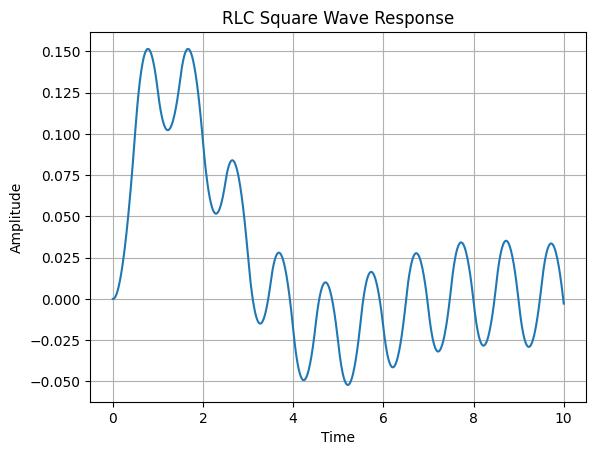

In [174]:
# RLC System
sys = cu.rlc_series(R=1, L=1, C=1)

t = sig.time_vector()
u = sig.square_wave(t)

t, y = cu.forced_response(sys, t, u)
plot.plot_time(t, y, "RLC Square Wave Response")

## 4. Interactive Playground

In [175]:
# Interactive Playground
def playground(a=1, b=1):
    sys = cu.make_TransferFunction([1, 0, a**2], [1, 2 * a * b, a**2])

    t, y = cu.step_response(sys)
    plot.plot_time(t, y, f"a={a}, b={b}")


widgets.interact(playground, k=(0.1, 10, 0.1), a=(0.1, 10, 0.1), b=(0.1, 10, 0.1))

interactive(children=(FloatSlider(value=1.0, description='a', max=10.0, min=0.1), FloatSlider(value=1.0, descr…

<function __main__.playground(a=1, b=1)>